![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 2.0. Coupler Design

## 0. Imports 

### 0.1. General libraries

**Run only the first time you execute this Jupyter Notebook**
You can delete this command lines after succesfully installing this tools

In [ ]:
# !sudo apt-get install libgomp1
# !sudo apt-get install libxft2
# !sudo apt-get install libglu1

Run everytime you start to execute this Jupyter Notebook

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


### 0.2. Functions by us

In [ ]:
from upvfab_design_tools import MMI_EME, DC_EME

## LO.6. 2x2 Multimode Interference Coupler

### LO.6.1 Propagation Simulation

For the multimode interference (MMI) couplers we must rely on the design tables shown on the theoretical session: 

<img src="mmi.png" alt="Design tables for MMI couplers" width="600">

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [ ]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 6.6 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 20 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

In [ ]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi # STUDENT

# Run propagation
m.propagation()

### LO.6.2. 2x2 Multimode Interference Coupler - Optimization

In [ ]:
dy = 0.1
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.dL_MMI = -1  # STUDENT

# Run propagation
m.propagation()

### LO.6.3 2x2 Multimode Interference Coupler – Optimization (II)

In [ ]:
# Design flow for MMI

m = MMI_EME()
m.MMI_width = 6.6   # MMI width
m.wg_width_dw = 0.2 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

In [ ]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 2 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0.1
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi  # STUDENT
m.dL_MMI = -0.5 # STUDENT

# Run propagation
m.propagation()

## Annex 1. Layout and connection to tidy3d using photonforge

In [ ]:
import gdsfactory as gf
import gplugins.tidy3d as gt

from upvfab.sin300.cband import PDK, cells, LAYER

In [ ]:
@gf.cell
def upvfab_mmi2x2(
    w_wg = 1.0,
    w_t = 1.0,
    l_io = 20.0,
    W_MMI_0 = 6.0,
    W_MMI_1 = 6.0,
    L_MMI = 50.0,
    dL_MMI = 0.0,
    IO_rel_pos = 1/6,
    dY_io = 0 
):
    # Draw the component - only half 
    c = gf.Component()
    L = (L_MMI+dL_MMI)
    X_io = -L/2.0-l_io
    Y_io = +IO_rel_pos*W_MMI_0+dY_io
    BODY = gf.components.taper(
        length = L/2.0,
        width1 = W_MMI_0,
        width2 = W_MMI_1,
        cross_section = 'strip'
    )

    IOWVG =  gf.components.taper(
        length = l_io,
        width1 = w_wg,
        width2 = w_t,
        cross_section = 'strip'
    )

    B = c.add_ref(BODY).movex(-L/2.0)
    IO1 = c.add_ref(IOWVG).move((X_io,+Y_io))
    IO2 = c.add_ref(IOWVG).move((X_io,-Y_io))

    # Two halves is one :)
    mmi = gf.Component()

    L = mmi.add_ref(c)
    R = mmi.add_ref(c).mirror_x()    
    
    mmi.flatten()

    # Add ports
    mmi.add_port(
        name="o1",
        center=(X_io,-Y_io),
        width = w_wg,
        orientation = 180,
        layer = LAYER.WG,
        port_type = "optical"
        )
    mmi.add_port(
        name="o2",
        center=(X_io,+Y_io),
        width = w_wg,
        orientation = 180,
        layer = LAYER.WG,
        port_type = "optical"
        )
    mmi.add_port(
        name="o4",
        center=(-X_io,-Y_io),
        width = w_wg,
        orientation = 0,
        layer = LAYER.WG,
        port_type = "optical"
        )
    mmi.add_port(
        name="o3",
        center=(-X_io,+Y_io),
        width = w_wg,
        orientation = 0,
        layer = LAYER.WG,
        port_type = "optical"
        )
    return(mmi)

mmi = upvfab_mmi2x2(L_MMI = 25)
mmi.draw_ports()
mmi.plot()
mmi.write_gds("mmi2x2.gds")

In [ ]:
sp = gt.write_sparameters(
    component=mmi,
    filepath="my_component.npz",
)

In [ ]:
# @gf.cell
# def upvfab_mmi1x2(
#     w_wg = 1.0,
#     w_t = 2.0,
#     l_io = 20.0,
#     W_MMI_0 = 6.0,
#     W_MMI_1 = 6.0,
#     L_MMI = 50.0,
#     dL_MMI = 0.0,
#     IO_rel_pos = 1/3,
#     dY_io = 0 
# ):
#     # Draw the component - only half 
#     c = gf.Component()
#     L = (L_MMI+dL_MMI)
#     X_io = -L/2.0-l_io
#     Y_io = +IO_rel_pos*W_MMI_0+dY_io
#     BODY = gf.components.taper(
#         length = L/2.0,
#         width1 = W_MMI_0,
#         width2 = W_MMI_1,
#         cross_section = 'strip'
#     )

#     IOWVG =  gf.components.taper(
#         length = l_io,
#         width1 = w_wg,
#         width2 = w_t,
#         cross_section = 'strip'
#     )

#     B1 = c.add_ref(BODY).movex(-L/2.0)
#     B2 = c.add_ref(BODY).movex(-L/2.0)
#     B2.mirror_x()
#     # IO1 = c.add_ref(IOWVG).move((-X_io,+Y_io))
#     # IO2 = c.add_ref(IOWVG).move((-X_io,-Y_io))
#     IO3 = c.add_ref(IOWVG).move((+X_io,0.0))
#     IO1 = c.add_ref(IOWVG).mirror_x()
#     IO1.move((+L/2.0,+Y_io))
#     IO2 = c.add_ref(IOWVG).mirror_x()
#     IO2.move((+L/2.0,-Y_io))

#     #c.flatten()

#     # Add ports
#     c.add_port(
#         name="o1",
#         center=(X_io,-Y_io),
#         width = w_wg,
#         orientation = 180,
#         layer = LAYER.WG,
#         port_type = "optical"
#         )
#     c.add_port(
#         name="o2",
#         center=(X_io,+Y_io),
#         width = w_wg,
#         orientation = 180,
#         layer = LAYER.WG,
#         port_type = "optical"
#         )
#     c.add_port(
#         name="o4",
#         center=(-X_io,-Y_io),
#         width = w_wg,
#         orientation = 0,
#         layer = LAYER.WG,
#         port_type = "optical"
#         )
#     c.add_port(
#         name="o3",
#         center=(-X_io,+Y_io),
#         width = w_wg,
#         orientation = 0,
#         layer = LAYER.WG,
#         port_type = "optical"
#         )
#     return(c)

# mmi1x2 = upvfab_mmi1x2()
# mmi1x2.plot()

In [ ]:
from gplugins.common.utils.plot import plot_sparameters
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
print(sp.keys())

In [ ]:
keys = ('o1@0,o4@0', 'o1@0,o3@0', 'o2@0,o4@0', 'o2@0,o3@0')
# plot_sparameters(sp,keys = keys, logscale=False)
# plt.ylim(0, 1)

wl = sp["wavelengths"]

plt.plot(wl, np.abs(sp["o1@0,o3@0"])**2, label="|S31|²")
plt.plot(wl, np.abs(sp["o1@0,o4@0"])**2, label="|S41|²")

plt.ylim(0, 1)
plt.xlabel("Wavelength [µm]")
plt.ylabel("Power transmission |S|²")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
mmi2x2_gral = upvfab_mmi2x2(w_wg = 1, w_t = 2.0, W_MMI_0 = 6.0, W_MMI_1 = 7.0)
mmi2x2_gral.plot()

## Annex 2. Aproximación a MMI con vértices para GDSfactory / tidy3D (ayudado por chatGPT)

In [ ]:
def mmi2x2_vertices(L, l_io, y_io, w_wg=1.0, w_t=2.0, W_MMI_0=6.0, W_MMI_1=7.0):
    x0 = -L / 2
    x1 =  L / 2
    xL = x0 - l_io
    xR = x1 + l_io

    # MMI central, permitiendo que el ancho en la entrada/salida sea W_MMI_0
    # y el ancho máximo/interior sea W_MMI_1.
    # Si quieres un MMI rectangular, pon W_MMI_0 = W_MMI_1.
    mmi = [
        (x0, -W_MMI_0 / 2),
        (0,  -W_MMI_1 / 2),
        (x1, -W_MMI_0 / 2),
        (x1,  W_MMI_0 / 2),
        (0,   W_MMI_1 / 2),
        (x0,  W_MMI_0 / 2),
    ]

    # Entrada superior
    in_top = [
        (xL, y_io - w_wg / 2),
        (x0, y_io - w_t / 2),
        (x0, y_io + w_t / 2),
        (xL, y_io + w_wg / 2),
    ]

    # Entrada inferior
    in_bot = [
        (xL, -y_io - w_wg / 2),
        (x0, -y_io - w_t / 2),
        (x0, -y_io + w_t / 2),
        (xL, -y_io + w_wg / 2),
    ]

    # Salida superior
    out_top = [
        (x1, y_io - w_t / 2),
        (xR, y_io - w_wg / 2),
        (xR, y_io + w_wg / 2),
        (x1, y_io + w_t / 2),
    ]

    # Salida inferior
    out_bot = [
        (x1, -y_io - w_t / 2),
        (xR, -y_io - w_wg / 2),
        (xR, -y_io + w_wg / 2),
        (x1, -y_io + w_t / 2),
    ]

    return {
        "mmi": mmi,
        "in_top": in_top,
        "in_bot": in_bot,
        "out_top": out_top,
        "out_bot": out_bot,
    }

In [ ]:
import gdsfactory as gf

L = 30
l_io = 15
y_io = 1.5

polys = mmi2x2_vertices(
    L=L,
    l_io=l_io,
    y_io=y_io,
    w_wg=1.0,
    w_t=2.0,
    W_MMI_0=6.0,
    W_MMI_1=7.0,
)

c = gf.Component("mmi2x2_vertices")

for poly in polys.values():
    c.add_polygon(poly, layer="WG")

c.plot()

In [ ]:
import tidy3d as td

sin = td.Medium(permittivity=2.0**2)

structures = []

for poly in polys.values():
    structures.append(
        td.Structure(
            geometry=td.PolySlab(
                vertices=poly,
                axis=2,
                slab_bounds=(-0.15, 0.15),
            ),
            medium=sin,
        )
    )

In [ ]:
# import matplotlib.pyplot as plt

# fig, ax = plt.subplots()

# for structure in structures:
#     structure.plot(z=0.11, ax=ax)

# ax.set_aspect("equal")
# plt.show()

In [ ]:
# import matplotlib.pyplot as plt

# for name, structure in zip(polys.keys(), structures):
#     fig, ax = plt.subplots(figsize=(8, 2))
#     structure.plot(z=0.11, ax=ax)
#     ax.set_aspect("equal")
#     ax.grid(True)
#     ax.set_title(name)
#     plt.show()

In [ ]:
sim = td.Simulation(
    size=(80, 20, 2),
    center=(0, 0, 0.11),
    structures=list(structures.values()) if isinstance(structures, dict) else structures,
    sources=[],
    monitors=[],
    run_time=1e-12,
    grid_spec=td.GridSpec.auto(wavelength=1.55),
)

sim.plot_eps(z=0)
plt.axis("equal")
plt.grid(True)
plt.show()

In [ ]:
import tidy3d as td

n_sin = 2.0      # ajusta al valor que quieras
n_sio2 = 1.444   # sílice aprox. a 1.55 µm

sin = td.Medium(permittivity=n_sin**2)
sio2 = td.Medium(permittivity=n_sio2**2)

In [ ]:
structures = []

for poly in polys.values():
    structures.append(
        td.Structure(
            geometry=td.PolySlab(
                vertices=poly,
                axis=2,
                slab_bounds=(-0.15, 0.15),
            ),
            medium=sin,
        )
    )

In [ ]:
import numpy as np

all_points = np.array([p for poly in polys.values() for p in poly])

xmin, ymin = all_points.min(axis=0)
xmax, ymax = all_points.max(axis=0)

print(xmin, xmax, ymin, ymax)

In [ ]:
pad_x = 2.0   # µm extra a izquierda y derecha
pad_y = 2.0   # µm extra arriba y abajo
pad_z = 1.0   # µm de sílice arriba y abajo del núcleo

In [ ]:
x_min_sim = xmin - pad_x
x_max_sim = xmax + pad_x

y_min_sim = ymin - pad_y
y_max_sim = ymax + pad_y

z_min_sim = -0.15 - pad_z
z_max_sim =  0.15 + pad_z

sim_center = (
    (x_min_sim + x_max_sim) / 2,
    (y_min_sim + y_max_sim) / 2,
    (z_min_sim + z_max_sim) / 2,
)

sim_size = (
    x_max_sim - x_min_sim,
    y_max_sim - y_min_sim,
    z_max_sim - z_min_sim,
)

print("center =", sim_center)
print("size =", sim_size)

In [ ]:
sim = td.Simulation(
    size=sim_size,
    center=sim_center,
    medium=sio2,              # fondo de sílice
    structures=structures,    # solo SiN
    sources=[],
    monitors=[],
    run_time=1e-12,
    grid_spec=td.GridSpec.auto(wavelength=1.55),
    boundary_spec=td.BoundarySpec.all_sides(
        boundary=td.PML()
    ),
)

In [ ]:
import matplotlib.pyplot as plt

sim.plot_eps(z=0)
plt.axis("equal")
plt.show()

In [ ]:
import tidy3d as td
import numpy as np

wavelength = 1.55  # um
freq0 = td.C_0 / wavelength
fwidth = freq0 / 10

source_time = td.GaussianPulse(
    freq0=freq0,
    fwidth=fwidth,
)

mode_spec = td.ModeSpec(
    num_modes=1,
)

In [ ]:
L
l_io
y_io
w_wg = 1.0

In [ ]:
x_mmi_left = -L / 2
x_mmi_right = L / 2

x_left = x_mmi_left - l_io
x_right = x_mmi_right + l_io

# Colocamos la fuente dentro de la guía recta de entrada,
# no demasiado cerca del borde/PML.
x_source = x_left + 1.0

# Colocamos monitores dentro de las guías rectas de salida.
x_monitor = x_right - 1.0

In [ ]:
mode_source = td.ModeSource(
    center=(x_source, y_io, 0),
    size=(0, 4 * w_wg, 2.0),
    source_time=source_time,
    direction="+",
    mode_spec=mode_spec,
    mode_index=0,
    name="mode_source_top",
)

In [ ]:
flux_monitor_top = td.FluxMonitor(
    center=(x_monitor, y_io, 0),
    size=(0, 4 * w_wg, 2.0),
    freqs=[freq0],
    name="flux_top",
)

flux_monitor_bottom = td.FluxMonitor(
    center=(x_monitor, -y_io, 0),
    size=(0, 4 * w_wg, 2.0),
    freqs=[freq0],
    name="flux_bottom",
)

In [ ]:
field_monitor = td.FieldMonitor(
    center=(sim_center[0], sim_center[1], 0),
    size=(sim_size[0], sim_size[1], 0),
    freqs=[freq0],
    name="field_z0",
)

In [ ]:
sim = td.Simulation(
    size=sim_size,
    center=sim_center,
    medium=sio2,
    structures=structures,
    sources=[mode_source],
    monitors=[
        flux_monitor_top,
        flux_monitor_bottom,
        field_monitor,
    ],
    run_time=2e-12,
    grid_spec=td.GridSpec.auto(wavelength=wavelength),
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
)

In [ ]:
import matplotlib.pyplot as plt

sim.plot_eps(z=0)
plt.axis("equal")
plt.show()

In [ ]:
sim.plot(z=0)
plt.axis("equal")
plt.show()

In [ ]:
mode_monitor_top = td.ModeMonitor(
    center=(x_monitor, y_io, 0),
    size=(0, 4 * w_wg, 2.0),
    freqs=[freq0],
    mode_spec=mode_spec,
    name="mode_top",
)

mode_monitor_bottom = td.ModeMonitor(
    center=(x_monitor, -y_io, 0),
    size=(0, 4 * w_wg, 2.0),
    freqs=[freq0],
    mode_spec=mode_spec,
    name="mode_bottom",
)

In [ ]:
monitors=[
    flux_monitor_top,
    flux_monitor_bottom,
    mode_monitor_top,
    mode_monitor_bottom,
    field_monitor,
]

In [ ]:
sim.validate_pre_upload()

In [ ]:
import tidy3d.web as web

sim_data = web.run(
    sim,
    task_name="mmi2x2_test",
    path="mmi2x2_test.hdf5",
    verbose=True,
)

In [ ]:
print(sim_data)
print(sim_data.monitor_data.keys())

In [ ]:
field = sim_data["field_z0"]

field.Ey.abs.plot()
plt.axis("equal")
plt.show()

In [ ]:
field = sim_data["field_z0"]

field.Ey.abs.plot()
plt.axis("equal")
plt.show()

In [ ]:
flux_top = sim_data["flux_top"].flux
flux_bottom = sim_data["flux_bottom"].flux

print("flux_top =", flux_top.values)
print("flux_bottom =", flux_bottom.values)

In [ ]:
P_top = float(flux_top.values[0])
P_bottom = float(flux_bottom.values[0])

print("P_top =", P_top)
print("P_bottom =", P_bottom)
print("P_total =", P_top + P_bottom)

## Annex 3. Todo en una Clase (hecho por chatGPT)

In [2]:
import gdsfactory as gf
import gplugins.tidy3d as gt

from upvfab.sin300.cband import PDK, cells, LAYER

from dataclasses import dataclass
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import gdsfactory as gf
import tidy3d as td
import tidy3d.web as web


@dataclass
class MMI2x2Tidy3D:
    # Geometry
    L: float = 30.0              # MMI length [um]
    l_io: float = 15.0           # input/output taper length [um]
    y_io: float = 1.5            # vertical position of I/O waveguide centers [um]
    w_wg: float = 1.0            # access waveguide width [um]
    w_t: float = 2.0             # taper width at MMI interface [um]
    W_MMI_0: float = 6.0         # MMI width at input/output ends [um]
    W_MMI_1: float = 7.0         # MMI width at center [um]

    # Layers / materials
    layer: tuple = (1, 0)
    core_thickness: float = 0.3  # SiN thickness [um]
    n_core: float = 2.0          # SiN refractive index
    n_clad: float = 1.444        # SiO2 refractive index

    # Simulation
    wavelength: float = 1.55     # central wavelength [um]
    bandwidth: float = 0.1       # approximate wavelength bandwidth [um]
    pad_x: float = 2.0
    pad_y: float = 2.0
    pad_z: float = 1.0
    run_time: float = 2e-12

    def vertices(self):
        """Return all 2D polygons used for layout and Tidy3D."""
        L = self.L
        l_io = self.l_io
        y = self.y_io
        w_wg = self.w_wg
        w_t = self.w_t
        W0 = self.W_MMI_0
        W1 = self.W_MMI_1

        x0 = -L / 2
        x1 = L / 2
        xL = x0 - l_io
        xR = x1 + l_io

        # Central MMI body.
        # If W_MMI_0 == W_MMI_1 this is effectively rectangular.
        mmi = [
            (x0, -W0 / 2),
            (0,  -W1 / 2),
            (x1, -W0 / 2),
            (x1,  W0 / 2),
            (0,   W1 / 2),
            (x0,  W0 / 2),
        ]

        in_top = [
            (xL, y - w_wg / 2),
            (x0, y - w_t / 2),
            (x0, y + w_t / 2),
            (xL, y + w_wg / 2),
        ]

        in_bot = [
            (xL, -y - w_wg / 2),
            (x0, -y - w_t / 2),
            (x0, -y + w_t / 2),
            (xL, -y + w_wg / 2),
        ]

        out_top = [
            (x1, y - w_t / 2),
            (xR, y - w_wg / 2),
            (xR, y + w_wg / 2),
            (x1, y + w_t / 2),
        ]

        out_bot = [
            (x1, -y - w_t / 2),
            (xR, -y - w_wg / 2),
            (xR, -y + w_wg / 2),
            (x1, -y + w_t / 2),
        ]

        return {
            "mmi": mmi,
            "in_top": in_top,
            "in_bot": in_bot,
            "out_top": out_top,
            "out_bot": out_bot,
        }
    
    def component(self, name="mmi2x2"):
        """Create a gdsfactory Component with polygons and optical ports."""
        c = gf.Component(name)
        polys = self.vertices()

        for poly in polys.values():
            c.add_polygon(poly, layer=self.layer)

        x0 = -self.L / 2
        x1 = self.L / 2
        xL = x0 - self.l_io
        xR = x1 + self.l_io
        y = self.y_io

        c.add_port(
            name="o1",
            center=(xL, y),
            width=self.w_wg,
            orientation=180,
            layer=self.layer,
            port_type="optical",
        )

        c.add_port(
            name="o2",
            center=(xL, -y),
            width=self.w_wg,
            orientation=180,
            layer=self.layer,
            port_type="optical",
        )

        c.add_port(
            name="o3",
            center=(xR, y),
            width=self.w_wg,
            orientation=0,
            layer=self.layer,
            port_type="optical",
        )

        c.add_port(
            name="o4",
            center=(xR, -y),
            width=self.w_wg,
            orientation=0,
            layer=self.layer,
            port_type="optical",
        )

        return c

    def plot_layout(self, with_ports=True):
        """Plot the gdsfactory layout."""
        c = self.component()

        if with_ports:
            c = c.copy()
            c.draw_ports()

        c.plot()
        return c

    def write_gds(self, filepath="mmi2x2.gds"):
        """Write layout to GDS."""
        c = self.component()
        c.write_gds(filepath)
        return filepath

    def tidy3d_structures(self):
        """Convert the same polygons into Tidy3D SiN PolySlab structures."""
        sin = td.Medium(permittivity=self.n_core**2)

        zmin = -self.core_thickness / 2
        zmax = self.core_thickness / 2

        structures = {}

        for name, poly in self.vertices().items():
            structures[name] = td.Structure(
                geometry=td.PolySlab(
                    vertices=poly,
                    axis=2,
                    slab_bounds=(zmin, zmax),
                ),
                medium=sin,
            )

        return structures

    def simulation_bounds(self):
        """Automatically compute compact simulation center and size."""
        polys = self.vertices()
        all_points = np.array([p for poly in polys.values() for p in poly])

        xmin, ymin = all_points.min(axis=0)
        xmax, ymax = all_points.max(axis=0)

        zmin_core = -self.core_thickness / 2
        zmax_core = self.core_thickness / 2

        x_min_sim = xmin - self.pad_x
        x_max_sim = xmax + self.pad_x

        y_min_sim = ymin - self.pad_y
        y_max_sim = ymax + self.pad_y

        z_min_sim = zmin_core - self.pad_z
        z_max_sim = zmax_core + self.pad_z

        center = (
            (x_min_sim + x_max_sim) / 2,
            (y_min_sim + y_max_sim) / 2,
            (z_min_sim + z_max_sim) / 2,
        )

        size = (
            x_max_sim - x_min_sim,
            y_max_sim - y_min_sim,
            z_max_sim - z_min_sim,
        )

        return center, size

    def make_sources_and_monitors(self, input_port="top"):
        """Create one ModeSource, two FluxMonitors, two ModeMonitors, and one FieldMonitor."""
        freq0 = td.C_0 / self.wavelength

        # Approximate frequency width from wavelength bandwidth
        fwidth = td.C_0 / self.wavelength**2 * self.bandwidth

        source_time = td.GaussianPulse(
            freq0=freq0,
            fwidth=fwidth,
        )

        mode_spec = td.ModeSpec(num_modes=1)

        x0 = -self.L / 2
        x1 = self.L / 2
        xL = x0 - self.l_io
        xR = x1 + self.l_io

        # Keep source and monitors away from PML.
        x_source = xL + 1.0
        x_monitor = xR - 1.0
        x_ref_monitor = x_source - 1.0

        if input_port == "top":
            y_source = self.y_io
            source_name = "mode_source_top"
        elif input_port == "bottom":
            y_source = -self.y_io
            source_name = "mode_source_bottom"
        else:
            raise ValueError("input_port must be 'top' or 'bottom'.")

        source_size = (
            0,
            max(4 * self.w_wg, 3.0),
            self.core_thickness + 2 * self.pad_z,
        )

        monitor_size = source_size

        mode_source = td.ModeSource(
            center=(x_source, y_source, 0),
            size=source_size,
            source_time=source_time,
            direction="+",
            mode_spec=mode_spec,
            mode_index=0,
            name=source_name,
        )

        flux_top = td.FluxMonitor(
            center=(x_monitor, self.y_io, 0),
            size=monitor_size,
            freqs=[freq0],
            name="flux_top",
        )

        flux_bottom = td.FluxMonitor(
            center=(x_monitor, -self.y_io, 0),
            size=monitor_size,
            freqs=[freq0],
            name="flux_bottom",
        )

        mode_top = td.ModeMonitor(
            center=(x_monitor, self.y_io, 0),
            size=monitor_size,
            freqs=[freq0],
            mode_spec=mode_spec,
            name="mode_top",
        )

        mode_bottom = td.ModeMonitor(
            center=(x_monitor, -self.y_io, 0),
            size=monitor_size,
            freqs=[freq0],
            mode_spec=mode_spec,
            name="mode_bottom",
        )

        flux_reflection = td.FluxMonitor(
            center=(x_ref_monitor, y_source, 0),
            size=monitor_size,
            freqs=[freq0],
            name="flux_reflection",
        )

        mode_reflection = td.ModeMonitor(
            center=(x_ref_monitor, y_source, 0),
            size=monitor_size,
            freqs=[freq0],
            mode_spec=mode_spec,
            name="mode_reflection",
        )

        sim_center, sim_size = self.simulation_bounds()

        field_z0 = td.FieldMonitor(
            center=(sim_center[0], sim_center[1], 0),
            size=(sim_size[0], sim_size[1], 0),
            freqs=[freq0],
            name="field_z0",
        )

        sources = [mode_source]
        
        monitors = [
            flux_reflection,
            mode_reflection,
            flux_top,
            flux_bottom,
            mode_top,
            mode_bottom,
            field_z0,
        ]

        return sources, monitors

    def simulation(self, input_port="top"):
        """Build full Tidy3D Simulation."""
        sio2 = td.Medium(permittivity=self.n_clad**2)

        structures_dict = self.tidy3d_structures()
        structures = list(structures_dict.values())

        sim_center, sim_size = self.simulation_bounds()
        sources, monitors = self.make_sources_and_monitors(input_port=input_port)

        sim = td.Simulation(
            center=sim_center,
            size=sim_size,
            medium=sio2,
            structures=structures,
            sources=sources,
            monitors=monitors,
            run_time=self.run_time,
            grid_spec=td.GridSpec.auto(wavelength=self.wavelength),
            boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
        )

        return sim

    def plot_vertices(self):
        fig, ax = plt.subplots(figsize=(10, 3))

        for name, poly in self.vertices().items():
            pts = np.array(poly)
            pts_closed = np.vstack([pts, pts[0]])
            ax.plot(pts_closed[:, 0], pts_closed[:, 1], marker="o", label=name)

        ax.set_aspect("equal")
        ax.grid(True)
        ax.legend()
        plt.show()

    def plot_tidy3d_structures(self):
        """Plot only the Tidy3D structures at z=0."""
        structures = self.tidy3d_structures()

        fig, ax = plt.subplots(figsize=(10, 3))

        for s in structures.values():
            s.plot(z=0, ax=ax)

        ax.set_aspect("equal")
        ax.grid(True)
        plt.show()

    def plot_simulation(self, input_port="top"):
        """Plot simulation geometry and source/monitor placement."""
        sim = self.simulation(input_port=input_port)

        fig, ax = plt.subplots(figsize=(10, 3))
        sim.plot(z=0, ax=ax)
        ax.set_aspect("equal")
        ax.grid(True)
        plt.show()

        return sim

    def plot_eps(self, input_port="top"):
        """Plot permittivity in the central z=0 plane."""
        sim = self.simulation(input_port=input_port)

        fig, ax = plt.subplots(figsize=(10, 3))
        sim.plot_eps(z=0, ax=ax)
        ax.set_aspect("equal")
        ax.grid(True)
        plt.show()

        return sim

    def validate(self, input_port="top"):
        """Validate simulation before upload."""
        sim = self.simulation(input_port=input_port)
        sim.validate_pre_upload()
        return sim

    # def estimate_cost(self, task_name="mmi2x2_cost", input_port="top"):
    #     """Estimate Tidy3D cloud cost."""
    #     sim = self.simulation(input_port=input_port)
    #     sim.validate_pre_upload()
    #     return web.estimate_cost(sim, task_name=task_name)

    def estimate_cost(self, input_port="top", task_name="mmi2x2_cost", verbose=True):
        """Estimate Tidy3D cloud cost without running the simulation."""
        import tidy3d.web as web

        sim = self.simulation(input_port=input_port)
        sim.validate_pre_upload()

        job = web.Job(
            simulation=sim,
            task_name=task_name,
            verbose=verbose,
        )

        return job.estimate_cost(verbose=verbose)
    def run(self, task_name="mmi2x2", path="data/mmi2x2.hdf5", input_port="top", verbose=True):
        """Run simulation in Tidy3D cloud and download results."""
        Path(path).parent.mkdir(parents=True, exist_ok=True)

        sim = self.simulation(input_port=input_port)
        sim.validate_pre_upload()

        sim_data = web.run(
            sim,
            task_name=task_name,
            path=path,
            verbose=verbose,
        )

        return sim_data

    def plot_field_result(self, sim_data, component="Ey"):
        """Plot field monitor result at z=0."""
        field = sim_data["field_z0"]

        data = getattr(field, component)

        data.abs.plot()
        plt.axis("equal")
        plt.show()

    def print_fluxes(self, sim_data):
        """Print reflected and transmitted fluxes."""
        R = -float(sim_data["flux_reflection"].flux.values[0])
        T_top = float(sim_data["flux_top"].flux.values[0])
        T_bottom = float(sim_data["flux_bottom"].flux.values[0])

        print("R        =", R)
        print("T_top    =", T_top)
        print("T_bottom =", T_bottom)
        print("T_total  =", T_top + T_bottom)
        print("Balance  =", R + T_top + T_bottom)

        return R, T_top, T_bottom

In [3]:
mmi = MMI2x2Tidy3D(
    L=28,
    l_io=15,
    y_io=1.5,
    w_wg=1.0,
    w_t=1.0,
    W_MMI_0=6.0,
    W_MMI_1=6.0,
)

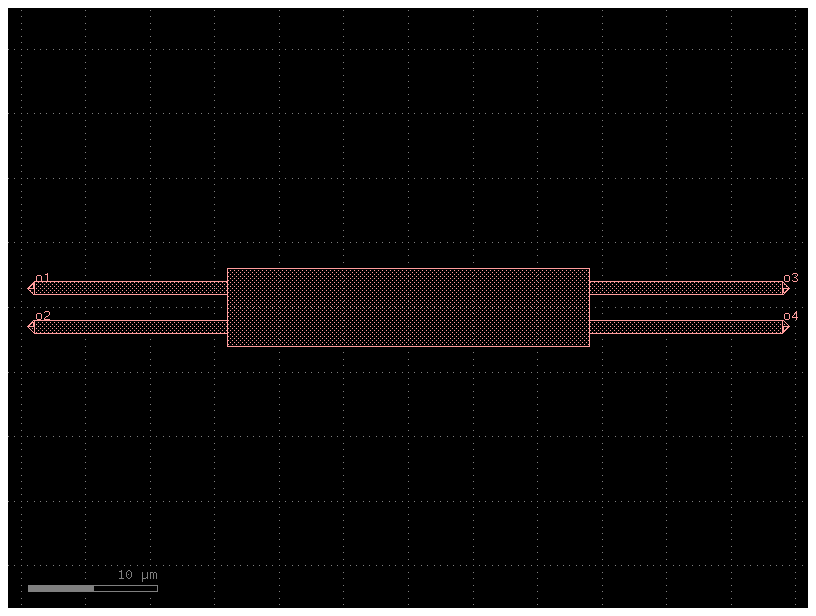

In [4]:
gf.clear_cache()

c = mmi.plot_layout(with_ports=True)

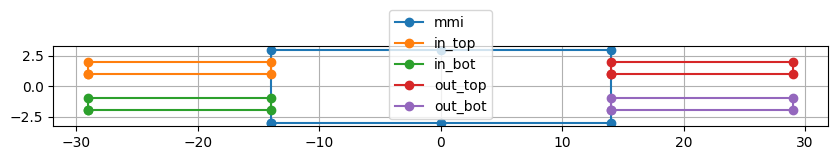

In [5]:
mmi.plot_vertices()

In [6]:
# mmi.plot_tidy3d_structures()

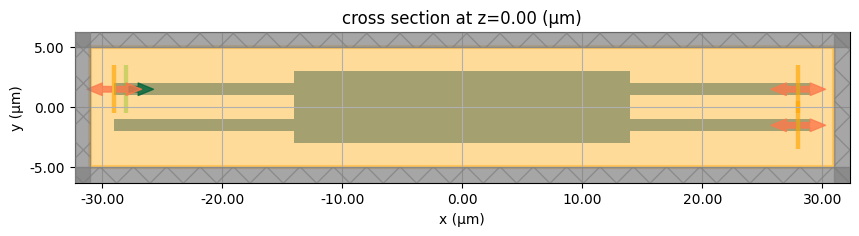

In [7]:
sim = mmi.plot_simulation(input_port="top")

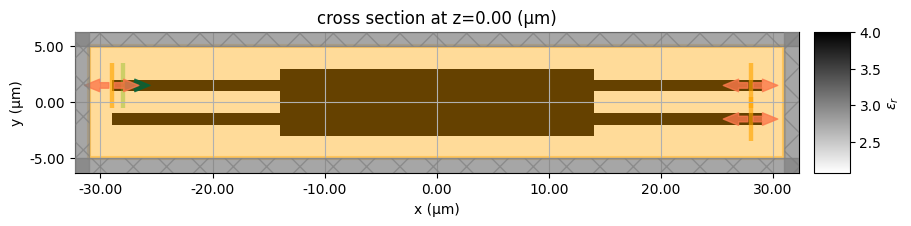

In [8]:
sim = mmi.plot_eps(input_port="top")

In [9]:
sim = mmi.validate(input_port="top")

In [10]:
cost = mmi.estimate_cost(
    task_name="mmi2x2_cost",
    input_port="top",
)

print(cost)

18:42:56 CEST Created task 'mmi2x2_cost' with resource_id                       
              'fdve-439029ca-b955-45e5-8cab-ea5a7dd78501' and task_type 'FDTD'.

              View task using web UI at                                         
              ]8;id=760750;https://tidy3d.simulation.cloud/workbench?taskId=fdve-439029ca-b955-45e5-8cab-ea5a7dd78501\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=821516;https://tidy3d.simulation.cloud/workbench?taskId=fdve-439029ca-b955-45e5-8cab-ea5a7dd78501\taskId]8;;\]8;id=760750;https://tidy3d.simulation.cloud/workbench?taskId=fdve-439029ca-b955-45e5-8cab-ea5a7dd78501\=]8;;\]8;id=536758;https://tidy3d.simulation.cloud/workbench?taskId=fdve-439029ca-b955-45e5-8cab-ea5a7dd78501\fdve]8;;\]8;id=760750;https://tidy3d.simulation.cloud/workbench?taskId=fdve-439029ca-b955-45e5-8cab-ea5a7dd78501\-439029ca-b9]8;;\
              ]8;id=760750;https://tidy3d.simulation.cloud/workbench?taskId=fdve-439029ca-b955-45e5-8cab-ea5a7dd78501\55-45e5-8cab-ea5a7dd78501']8;;\.

              Task folder: ]8;id=313771;https://tidy3d.simulation.cloud/folders/246cc199-3ac6-4a37-b061-d9357d447da2\'default']8;;\.

Output()

18:43:01 CEST Estimated FlexCredit cost: 0.039. Minimum cost depends on task    
              execution details. Use 'web.real_cost(task_id)' to get the billed 
              FlexCredit cost after a simulation run.

0.03857378777882131


In [11]:
sim_data = mmi.run(
    task_name="mmi2x2_test",
    path="data/mmi2x2_test.hdf5",
    input_port="top",
)

              Created task 'mmi2x2_test' with resource_id                       
              'fdve-61864642-7de0-430f-8a73-fc6f70a24a8d' and task_type 'FDTD'.

              View task using web UI at                                         
              ]8;id=227782;https://tidy3d.simulation.cloud/workbench?taskId=fdve-61864642-7de0-430f-8a73-fc6f70a24a8d\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=764119;https://tidy3d.simulation.cloud/workbench?taskId=fdve-61864642-7de0-430f-8a73-fc6f70a24a8d\taskId]8;;\]8;id=227782;https://tidy3d.simulation.cloud/workbench?taskId=fdve-61864642-7de0-430f-8a73-fc6f70a24a8d\=]8;;\]8;id=435591;https://tidy3d.simulation.cloud/workbench?taskId=fdve-61864642-7de0-430f-8a73-fc6f70a24a8d\fdve]8;;\]8;id=227782;https://tidy3d.simulation.cloud/workbench?taskId=fdve-61864642-7de0-430f-8a73-fc6f70a24a8d\-61864642-7d]8;;\
              ]8;id=227782;https://tidy3d.simulation.cloud/workbench?taskId=fdve-61864642-7de0-430f-8a73-fc6f70a24a8d\e0-430f-8a73-fc6f70a24a8d']8;;\.

              Task folder: ]8;id=374154;https://tidy3d.simulation.cloud/folders/246cc199-3ac6-4a37-b061-d9357d447da2\'default']8;;\.

Output()

18:43:04 CEST Estimated FlexCredit cost: 0.039. Minimum cost depends on task    
              execution details. Use 'web.real_cost(task_id)' to get the billed 
              FlexCredit cost after a simulation run.

...

18:43:29 CEST early shutoff detected at 61%, exiting.

18:43:30 CEST status = success

              View simulation result at                                         
              ]8;id=841415;https://tidy3d.simulation.cloud/workbench?taskId=fdve-61864642-7de0-430f-8a73-fc6f70a24a8d\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=961273;https://tidy3d.simulation.cloud/workbench?taskId=fdve-61864642-7de0-430f-8a73-fc6f70a24a8d\taskId]8;;\]8;id=841415;https://tidy3d.simulation.cloud/workbench?taskId=fdve-61864642-7de0-430f-8a73-fc6f70a24a8d\=]8;;\]8;id=64392;https://tidy3d.simulation.cloud/workbench?taskId=fdve-61864642-7de0-430f-8a73-fc6f70a24a8d\fdve]8;;\]8;id=841415;https://tidy3d.simulation.cloud/workbench?taskId=fdve-61864642-7de0-430f-8a73-fc6f70a24a8d\-61864642-7d]8;;\
              ]8;id=841415;https://tidy3d.simulation.cloud/workbench?taskId=fdve-61864642-7de0-430f-8a73-fc6f70a24a8d\e0-430f-8a73-fc6f70a24a8d']8;;\.

Output()

18:43:35 CEST Loading results from data/mmi2x2_test.hdf5

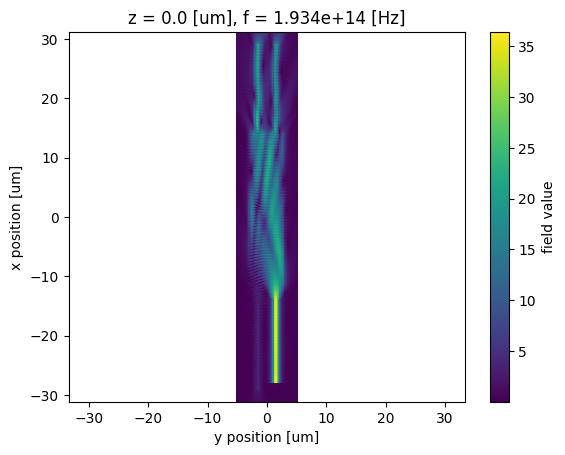

In [12]:
mmi.plot_field_result(sim_data, component="Ey")

In [13]:
mmi.print_fluxes(sim_data)

R        = 0.00014776879106648266
T_top    = 0.2897242605686188
T_bottom = 0.34730884432792664
T_total  = 0.6370331048965454
Balance  = 0.6371808736876119


(0.00014776879106648266, 0.2897242605686188, 0.34730884432792664)